 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

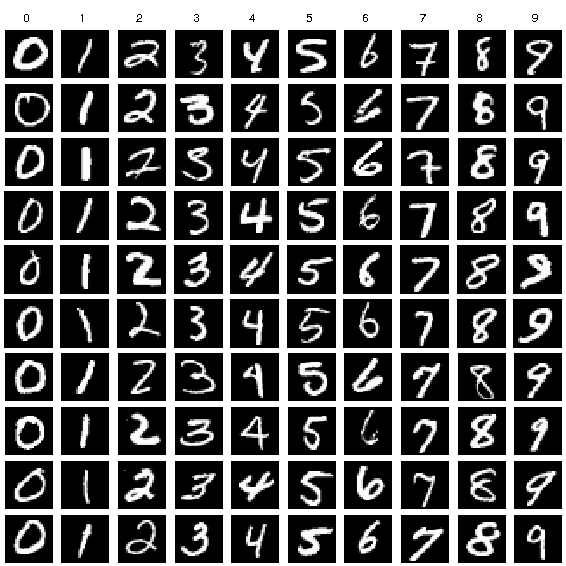

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #




###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [3]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

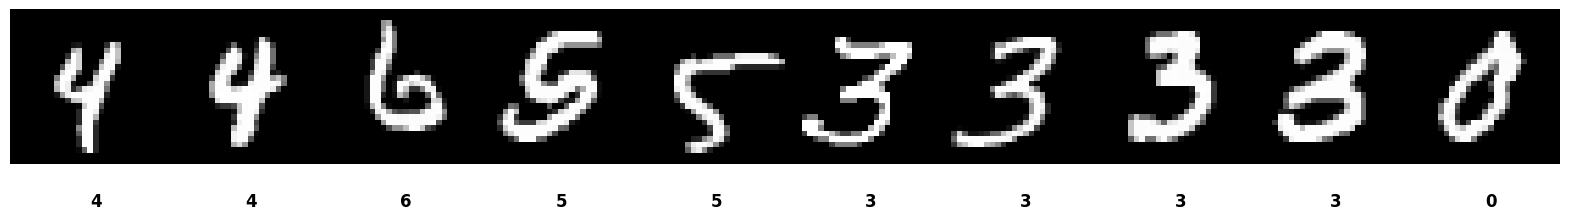

In [4]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

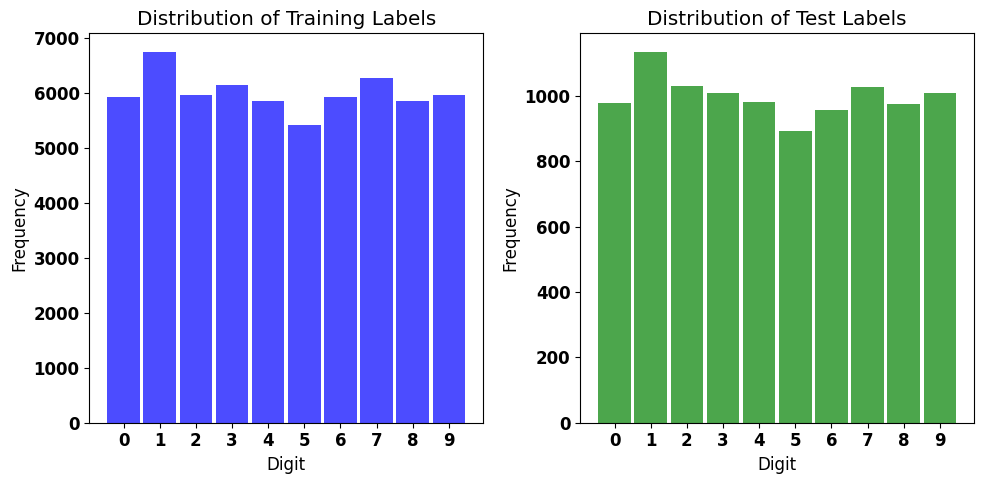

X_train shape: (60000, 28, 28, 1) | y_train shape: (60000, 10)
X_test shape:  (10000, 28, 28, 1) | y_test shape:  (10000, 10)


In [11]:
###################################
# Label distribution (before one-hot encoding)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=np.arange(11) - 0.5, color='blue', alpha=0.7, rwidth=0.9)
plt.title('Distribution of Training Labels')
plt.xlabel('Digit')
plt.ylabel('Frequency')
plt.xticks(range(10))

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=np.arange(11) - 0.5, color='green', alpha=0.7, rwidth=0.9)
plt.title('Distribution of Test Labels')
plt.xlabel('Digit')
plt.ylabel('Frequency')
plt.xticks(range(10))

plt.tight_layout()
plt.show()

# Keep integer labels for later evaluation (e.g., confusion matrix)
y_train_int = y_train.copy()
y_test_int = y_test.copy()

# Input preprocessing: min-max normalization + channel dimension
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = np.expand_dims(X_train, axis=-1)  # (N, 28, 28, 1)
X_test = np.expand_dims(X_test, axis=-1)    # (N, 28, 28, 1)

# Target preprocessing: one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train_int, num_classes=num_classes)
y_test = keras.utils.to_categorical(y_test_int, num_classes=num_classes)

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape,  "| y_test shape: ", y_test.shape)



###################################

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [12]:
model = Sequential()
###################################
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))

model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(num_classes, activation='softmax'))    
###################################


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem 

In [15]:
loss = None
optimizer = None
metrics = None
learning_rate = 0.0

###################################
# Write your own code here #
loss = keras.losses.CategoricalCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=0.001)
metrics = ['accuracy']  

model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [16]:
###################################
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1)
###################################

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.9329 - loss: 0.2302 - val_accuracy: 0.9828 - val_loss: 0.0607
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9803 - loss: 0.0620 - val_accuracy: 0.9852 - val_loss: 0.0530
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9853 - val_loss: 0.0442
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.9901 - loss: 0.0308 - val_accuracy: 0.9892 - val_loss: 0.0365
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9895 - val_loss: 0.0351
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9935 - loss: 0.0205 - val_accuracy: 0.9922 - val_loss: 0.0325
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9892 - val_loss: 0.0385
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9958 - loss: 0.0129 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

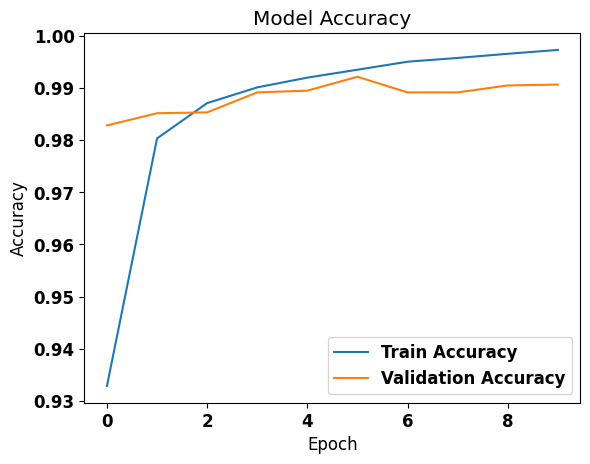

In [18]:
###################################
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()



###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9910 - loss: 0.0300
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


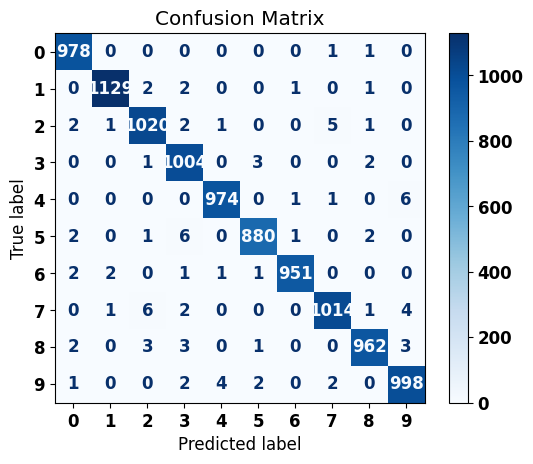

In [ ]:
###################################

#plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(num_classes))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
###################################

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it


=== Training: baseline ===
test_acc=0.9908, test_loss=0.0268, best_val_acc=0.9900, overfit_gap=0.0075

=== Training: dropout ===
test_acc=0.9930, test_loss=0.0234, best_val_acc=0.9925, overfit_gap=-0.0022

=== Training: l2+dropout ===
test_acc=0.9927, test_loss=0.0524, best_val_acc=0.9927, overfit_gap=-0.0020

=== Training: smaller+l1_l2 ===
test_acc=0.9913, test_loss=0.0524, best_val_acc=0.9913, overfit_gap=-0.0049

=== Experiment Summary (sorted by test_acc) ===
dropout        | test_acc=0.9930 | best_val_acc=0.9925 | gap=-0.0022 [OK] | epochs=10
l2+dropout     | test_acc=0.9927 | best_val_acc=0.9927 | gap=-0.0020 [OK] | epochs=12
smaller+l1_l2  | test_acc=0.9913 | best_val_acc=0.9913 | gap=-0.0049 [OK] | epochs=12
baseline       | test_acc=0.9908 | best_val_acc=0.9900 | gap=0.0075 [OK] | epochs=8


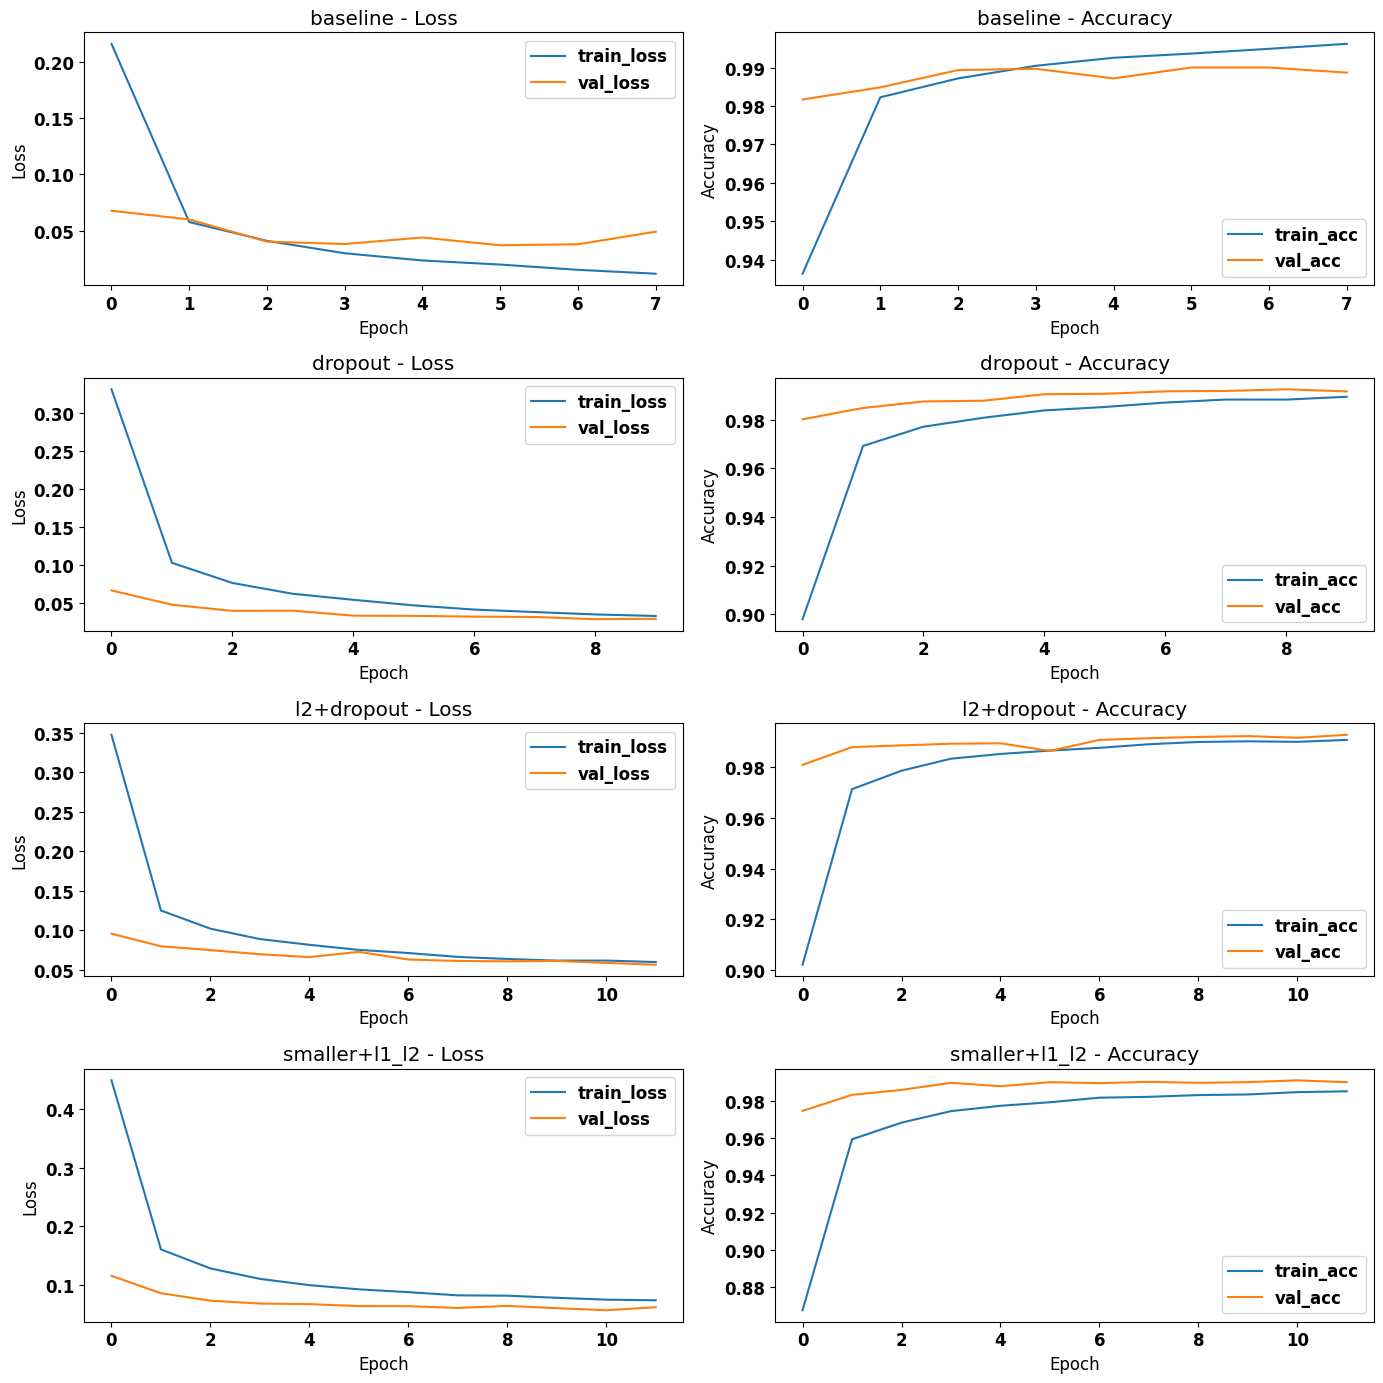


Selected model: dropout


In [21]:
# Hyperparameter tuning + architecture/regularization experiments

def build_cnn(cfg):
    reg = None
    if cfg["reg"] == "l1":
        reg = keras.regularizers.l1(cfg["reg_value"])
    elif cfg["reg"] == "l2":
        reg = keras.regularizers.l2(cfg["reg_value"])
    elif cfg["reg"] == "l1_l2":
        reg = keras.regularizers.l1_l2(l1=cfg["reg_value"][0], l2=cfg["reg_value"][1])

    m = keras.Sequential()
    m.add(keras.layers.Input(shape=(28, 28, 1)))

    for f in cfg["filters"]:
        m.add(keras.layers.Conv2D(f, (3, 3), activation="relu", kernel_regularizer=reg))
        m.add(keras.layers.MaxPooling2D((2, 2)))
        if cfg["dropout_conv"] > 0:
            m.add(keras.layers.Dropout(cfg["dropout_conv"]))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(cfg["dense_units"], activation="relu", kernel_regularizer=reg))
    if cfg["dropout_dense"] > 0:
        m.add(keras.layers.Dropout(cfg["dropout_dense"]))

    m.add(keras.layers.Dense(num_classes, activation="softmax"))

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


experiments = [
    {
        "name": "baseline",
        "filters": [32, 64],
        "dense_units": 128,
        "dropout_conv": 0.0,
        "dropout_dense": 0.0,
        "reg": None,
        "reg_value": None,
        "lr": 1e-3,
        "batch_size": 128,
        "epochs": 8,
    },
    {
        "name": "dropout",
        "filters": [32, 64],
        "dense_units": 128,
        "dropout_conv": 0.15,
        "dropout_dense": 0.4,
        "reg": None,
        "reg_value": None,
        "lr": 1e-3,
        "batch_size": 128,
        "epochs": 10,
    },
    {
        "name": "l2+dropout",
        "filters": [32, 64],
        "dense_units": 128,
        "dropout_conv": 0.1,
        "dropout_dense": 0.3,
        "reg": "l2",
        "reg_value": 1e-4,
        "lr": 8e-4,
        "batch_size": 128,
        "epochs": 12,
    },
    {
        "name": "smaller+l1_l2",
        "filters": [16, 32],
        "dense_units": 64,
        "dropout_conv": 0.1,
        "dropout_dense": 0.3,
        "reg": "l1_l2",
        "reg_value": (1e-6, 1e-4),
        "lr": 1e-3,
        "batch_size": 128,
        "epochs": 12,
    },
]

results = []
histories = {}
best_model = None
best_test_acc = -1.0

for cfg in experiments:
    print(f"\n=== Training: {cfg['name']} ===")
    temp_model = build_cnn(cfg)

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True
    )

    h = temp_model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        callbacks=[early_stop],
        verbose=0,
    )

    test_loss, test_acc = temp_model.evaluate(X_test, y_test, verbose=0)
    train_acc_last = h.history["accuracy"][-1]
    val_acc_last = h.history["val_accuracy"][-1]
    overfit_gap = train_acc_last - val_acc_last

    row = {
        "name": cfg["name"],
        "epochs_ran": len(h.history["loss"]),
        "best_val_acc": float(np.max(h.history["val_accuracy"])),
        "best_val_loss": float(np.min(h.history["val_loss"])),
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
        "overfit_gap": float(overfit_gap),
    }
    results.append(row)
    histories[cfg["name"]] = h

    print(
        f"test_acc={row['test_acc']:.4f}, test_loss={row['test_loss']:.4f}, "
        f"best_val_acc={row['best_val_acc']:.4f}, overfit_gap={row['overfit_gap']:.4f}"
    )

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model = temp_model

# Print summary sorted by test accuracy
results_sorted = sorted(results, key=lambda x: x["test_acc"], reverse=True)
print("\n=== Experiment Summary (sorted by test_acc) ===")
for r in results_sorted:
    flag = "OVERFIT" if (r["overfit_gap"] > 0.02) else "OK"
    print(
        f"{r['name']:<14} | test_acc={r['test_acc']:.4f} | "
        f"best_val_acc={r['best_val_acc']:.4f} | gap={r['overfit_gap']:.4f} [{flag}] | "
        f"epochs={r['epochs_ran']}"
    )

# Plot loss curves for overfitting inspection
n = len(experiments)
plt.figure(figsize=(14, 3.5 * n))
for i, cfg in enumerate(experiments, 1):
    h = histories[cfg["name"]]
    plt.subplot(n, 2, 2 * i - 1)
    plt.plot(h.history["loss"], label="train_loss")
    plt.plot(h.history["val_loss"], label="val_loss")
    plt.title(f"{cfg['name']} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(n, 2, 2 * i)
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(f"{cfg['name']} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

plt.tight_layout()
plt.show()

# Keep the best model for any next cells
model = best_model
print("\nSelected model:", results_sorted[0]["name"])